In [ ]:
# Let's get started dobby..!

In [ ]:
# resnet18 feature Extraction

In [2]:
# ============================================
# 🔹 Extract & Save Features using ResNet18
# ============================================

import torch
import torch.nn as nn
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader
import numpy as np
import os

# Paths
data_dir_tn = "/kaggle/input/braintumordataset/Training"  # replace with your dataset root
data_dir_ts = "/kaggle/input/braintumordataset/Testing"  # replace with your dataset root
save_dir = "features"
os.makedirs(save_dir, exist_ok=True)

# Transforms (standard ImageNet preprocessing)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# Datasets
train_data = datasets.ImageFolder(os.path.join(data_dir_tn), transform=transform)
test_data = datasets.ImageFolder(os.path.join(data_dir_ts), transform=transform)

train_loader = DataLoader(train_data, batch_size=64, shuffle=False)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

# Model (ResNet18 without classifier)
resnet = models.resnet18(pretrained=True)
resnet = nn.Sequential(*list(resnet.children())[:-1])  # remove FC layer
resnet.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
resnet.to(device)

def extract_features(model, dataloader):
    features, labels = [], []
    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device)
            out = model(x)
            out = out.view(out.size(0), -1)  # flatten
            features.append(out.cpu().numpy())
            labels.append(y.numpy())
    return np.concatenate(features), np.concatenate(labels)

# Extract train + test
train_features, train_labels = extract_features(resnet, train_loader)
test_features, test_labels = extract_features(resnet, test_loader)

# Save
np.save(os.path.join(save_dir, "resnet_train_features.npy"), train_features)
np.save(os.path.join(save_dir, "resnet_train_labels.npy"), train_labels)
np.save(os.path.join(save_dir, "resnet_test_features.npy"), test_features)
np.save(os.path.join(save_dir, "resnet_test_labels.npy"), test_labels)

print("✅ ResNet18 features saved successfully!")

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 167MB/s] 


✅ ResNet18 features saved successfully!


In [ ]:
# vgg16 feature Extraction

In [4]:
# ============================================
# 🔹 Extract & Save Features using VGG16
# ============================================

import torch
import torch.nn as nn
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader
import numpy as np
import os

# Paths
data_dir_tn = "/kaggle/input/braintumordataset/Training" 
data_dir_ts = "/kaggle/input/braintumordataset/Testing"
save_dir = "features"
os.makedirs(save_dir, exist_ok=True)

# Transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# Datasets
train_data = datasets.ImageFolder(os.path.join(data_dir_tn), transform=transform)
test_data = datasets.ImageFolder(os.path.join(data_dir_ts), transform=transform)

train_loader = DataLoader(train_data, batch_size=64, shuffle=False)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

# Model (VGG16 without classifier)
vgg = models.vgg16(pretrained=True).features  # only feature extractor
vgg.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vgg.to(device)

def extract_features(model, dataloader):
    features, labels = [], []
    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device)
            out = model(x)
            out = torch.flatten(out, 1)
            features.append(out.cpu().numpy())
            labels.append(y.numpy())
    return np.concatenate(features), np.concatenate(labels)

# Extract train + test
train_features, train_labels = extract_features(vgg, train_loader)
test_features, test_labels = extract_features(vgg, test_loader)

# Save
np.save(os.path.join(save_dir, "vgg_train_features.npy"), train_features)
np.save(os.path.join(save_dir, "vgg_train_labels.npy"), train_labels)
np.save(os.path.join(save_dir, "vgg_test_features.npy"), test_features)
np.save(os.path.join(save_dir, "vgg_test_labels.npy"), test_labels)

print("✅ VGG16 features saved successfully!")

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth
100%|██████████| 528M/528M [00:02<00:00, 217MB/s] 


✅ VGG16 features saved successfully!


In [ ]:
# EfficientNet-BO Feature Extraction

In [5]:
# ============================================
# 🔹 Extract & Save Features using EfficientNet-B0
# ============================================

import torch
import torch.nn as nn
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader
import numpy as np
import os

# Paths
data_dir_tn = "/kaggle/input/braintumordataset/Training" 
data_dir_ts = "/kaggle/input/braintumordataset/Testing" # replace with your dataset root
save_dir = "features"
os.makedirs(save_dir, exist_ok=True)

# Transforms (same 224×224 standard)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# Datasets
train_data = datasets.ImageFolder(os.path.join(data_dir), transform=transform)
test_data = datasets.ImageFolder(os.path.join(data_dir), transform=transform)

train_loader = DataLoader(train_data, batch_size=64, shuffle=False)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

# Model (EfficientNet-B0 without classifier)
efficientnet = models.efficientnet_b0(pretrained=True)
efficientnet = nn.Sequential(*list(efficientnet.children())[:-1])  # remove classifier head
efficientnet.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
efficientnet.to(device)

def extract_features(model, dataloader):
    features, labels = [], []
    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device)
            out = model(x)
            out = torch.flatten(out, 1)
            features.append(out.cpu().numpy())
            labels.append(y.numpy())
    return np.concatenate(features), np.concatenate(labels)

# Extract train + test
train_features, train_labels = extract_features(efficientnet, train_loader)
test_features, test_labels = extract_features(efficientnet, test_loader)

# Save
np.save(os.path.join(save_dir, "efficientnet_train_features.npy"), train_features)
np.save(os.path.join(save_dir, "efficientnet_train_labels.npy"), train_labels)
np.save(os.path.join(save_dir, "efficientnet_test_features.npy"), test_features)
np.save(os.path.join(save_dir, "efficientnet_test_labels.npy"), test_labels)

print("✅ EfficientNet-B0 features saved successfully!")

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 141MB/s] 


✅ EfficientNet-B0 features saved successfully!


In [ ]:
# Individual Evaluation dobby..!

In [ ]:
# resnet18 model Evaluation

In [6]:
# ===============================
# Phase 1: ML Model Evaluation on Extracted Features
# ===============================

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef, classification_report
from sklearn.preprocessing import StandardScaler

# ML Models
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# ===============================
# 1️⃣ Load Training & Testing Features
# ===============================
train_features = np.load("/kaggle/working/features/resnet_train_features.npy")
train_labels   = np.load("/kaggle/working/features/resnet_train_labels.npy")
test_features  = np.load("/kaggle/working/features/resnet_test_features.npy")
test_labels    = np.load("/kaggle/working/features/resnet_test_labels.npy")

print(f"Train Features: {train_features.shape}, Test Features: {test_features.shape}")

# Standardize
scaler = StandardScaler()
train_features = scaler.fit_transform(train_features)
test_features  = scaler.transform(test_features)

# ===============================
# 2️⃣ Define Models
# ===============================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(kernel='rbf', probability=True),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

# ===============================
# 3️⃣ Evaluation Function
# ===============================
def evaluate_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    acc  = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, average='weighted', zero_division=0)
    rec  = recall_score(y_test, preds, average='weighted', zero_division=0)
    f1   = f1_score(y_test, preds, average='weighted', zero_division=0)
    mcc  = matthews_corrcoef(y_test, preds)

    print(f"\n🔹 {model.__class__.__name__} Results:")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print(f"MCC:       {mcc:.4f}")
    print("-" * 50)

    return {
        "Model": model.__class__.__name__,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "MCC": mcc
    }

# ===============================
# 4️⃣ Run All Models
# ===============================
results = []
for name, clf in models.items():
    print(f"Training {name} ...")
    metrics = evaluate_model(clf, train_features, train_labels, test_features, test_labels)
    results.append(metrics)

# ===============================
# 5️⃣ Display Results as Table
# ===============================
import pandas as pd
results_df = pd.DataFrame(results)
print("\n✅ Summary of ML Model Performance:")
print(results_df)

Train Features: (5712, 512), Test Features: (1311, 512)
Training Logistic Regression ...

🔹 LogisticRegression Results:
Accuracy:  0.9329
Precision: 0.9337
Recall:    0.9329
F1-score:  0.9328
MCC:       0.9102
--------------------------------------------------
Training SVM ...

🔹 SVC Results:
Accuracy:  0.9512
Precision: 0.9525
Recall:    0.9512
F1-score:  0.9510
MCC:       0.9350
--------------------------------------------------
Training Random Forest ...

🔹 RandomForestClassifier Results:
Accuracy:  0.9245
Precision: 0.9281
Recall:    0.9245
F1-score:  0.9238
MCC:       0.9001
--------------------------------------------------
Training Gradient Boosting ...

🔹 GradientBoostingClassifier Results:
Accuracy:  0.9359
Precision: 0.9378
Recall:    0.9359
F1-score:  0.9358
MCC:       0.9146
--------------------------------------------------
Training XGBoost ...

🔹 XGBClassifier Results:
Accuracy:  0.9436
Precision: 0.9450
Recall:    0.9436
F1-score:  0.9434
MCC:       0.9248
--------------

In [ ]:
# vgg16 model Evaluation

In [2]:
# ===============================
# Phase 1: ML Model Evaluation on Extracted Features
# ===============================

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef, classification_report
from sklearn.preprocessing import StandardScaler

# ML Models
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# ===============================
# 1️⃣ Load Training & Testing Features
# ===============================
train_features = np.load("/kaggle/input/vgg16embeddings/vgg_train_features.npy")
train_labels   = np.load("/kaggle/input/vgg16embeddings/vgg_train_labels.npy")
test_features  = np.load("/kaggle/input/vgg16embeddings/vgg_test_features.npy")
test_labels    = np.load("/kaggle/input/vgg16embeddings/vgg_test_labels.npy")

print(f"Train Features: {train_features.shape}, Test Features: {test_features.shape}")

# Standardize
scaler = StandardScaler()
train_features = scaler.fit_transform(train_features)
test_features  = scaler.transform(test_features)

# ===============================
# 2️⃣ Define Models
# ===============================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(kernel='rbf', probability=True),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

# ===============================
# 3️⃣ Evaluation Function
# ===============================
def evaluate_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    acc  = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, average='weighted', zero_division=0)
    rec  = recall_score(y_test, preds, average='weighted', zero_division=0)
    f1   = f1_score(y_test, preds, average='weighted', zero_division=0)
    mcc  = matthews_corrcoef(y_test, preds)

    print(f"\n🔹 {model.__class__.__name__} Results:")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print(f"MCC:       {mcc:.4f}")
    print("-" * 50)

    return {
        "Model": model.__class__.__name__,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "MCC": mcc
    }

# ===============================
# 4️⃣ Run All Models
# ===============================
results = []
for name, clf in models.items():
    print(f"Training {name} ...")
    metrics = evaluate_model(clf, train_features, train_labels, test_features, test_labels)
    results.append(metrics)

# ===============================
# 5️⃣ Display Results as Table
# ===============================
import pandas as pd
results_df = pd.DataFrame(results)
print("\n✅ Summary of ML Model Performance:")
print(results_df)

Train Features: (5712, 25088), Test Features: (1311, 25088)
Training Logistic Regression ...

🔹 LogisticRegression Results:
Accuracy:  0.9634
Precision: 0.9638
Recall:    0.9634
F1-score:  0.9633
MCC:       0.9510
--------------------------------------------------
Training SVM ...

🔹 SVC Results:
Accuracy:  0.9169
Precision: 0.9222
Recall:    0.9169
F1-score:  0.9159
MCC:       0.8902
--------------------------------------------------
Training Random Forest ...

🔹 RandomForestClassifier Results:
Accuracy:  0.9207
Precision: 0.9222
Recall:    0.9207
F1-score:  0.9200
MCC:       0.8943
--------------------------------------------------
Training Gradient Boosting ...

🔹 GradientBoostingClassifier Results:
Accuracy:  0.9321
Precision: 0.9333
Recall:    0.9321
F1-score:  0.9317
MCC:       0.9094
--------------------------------------------------
Training XGBoost ...

🔹 XGBClassifier Results:
Accuracy:  0.9458
Precision: 0.9478
Recall:    0.9458
F1-score:  0.9457
MCC:       0.9280
----------

In [ ]:
# EfficientNet-BO model Evaluation

In [4]:
# ===============================
# Phase 1: ML Model Evaluation on Extracted Features
# ===============================

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef, classification_report
from sklearn.preprocessing import StandardScaler

# ML Models
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# ===============================
# 1️⃣ Load Training & Testing Features
# ===============================
train_features = np.load("/kaggle/input/efficientnet-boembeddings/efficientnet_train_features.npy")
train_labels   = np.load("/kaggle/input/efficientnet-boembeddings/efficientnet_train_labels.npy")
test_features  = np.load("/kaggle/input/efficientnet-boembeddings/efficientnet_test_features.npy")
test_labels    = np.load("/kaggle/input/efficientnet-boembeddings/efficientnet_test_labels.npy")

print(f"Train Features: {train_features.shape}, Test Features: {test_features.shape}")

# Standardize
scaler = StandardScaler()
train_features = scaler.fit_transform(train_features)
test_features  = scaler.transform(test_features)

# ===============================
# 2️⃣ Define Models
# ===============================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(kernel='rbf', probability=True),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

# ===============================
# 3️⃣ Evaluation Function
# ===============================
def evaluate_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    acc  = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, average='weighted', zero_division=0)
    rec  = recall_score(y_test, preds, average='weighted', zero_division=0)
    f1   = f1_score(y_test, preds, average='weighted', zero_division=0)
    mcc  = matthews_corrcoef(y_test, preds)

    print(f"\n🔹 {model.__class__.__name__} Results:")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print(f"MCC:       {mcc:.4f}")
    print("-" * 50)

    return {
        "Model": model.__class__.__name__,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "MCC": mcc
    }

# ===============================
# 4️⃣ Run All Models
# ===============================
results = []
for name, clf in models.items():
    print(f"Training {name} ...")
    metrics = evaluate_model(clf, train_features, train_labels, test_features, test_labels)
    results.append(metrics)

# ===============================
# 5️⃣ Display Results as Table
# ===============================
import pandas as pd
results_df = pd.DataFrame(results)
print("\n✅ Summary of ML Model Performance:")
print(results_df)

Train Features: (7023, 1280), Test Features: (7023, 1280)
Training Logistic Regression ...

🔹 LogisticRegression Results:
Accuracy:  0.8370
Precision: 0.8150
Recall:    0.8370
F1-score:  0.8104
MCC:       0.3515
--------------------------------------------------
Training SVM ...

🔹 SVC Results:
Accuracy:  0.8163
Precision: 0.8354
Recall:    0.8163
F1-score:  0.7372
MCC:       0.1125
--------------------------------------------------
Training Random Forest ...

🔹 RandomForestClassifier Results:
Accuracy:  0.9695
Precision: 0.9697
Recall:    0.9695
F1-score:  0.9688
MCC:       0.8975
--------------------------------------------------
Training Gradient Boosting ...

🔹 GradientBoostingClassifier Results:
Accuracy:  0.8488
Precision: 0.8705
Recall:    0.8488
F1-score:  0.8042
MCC:       0.3993
--------------------------------------------------
Training XGBoost ...

🔹 XGBClassifier Results:
Accuracy:  0.9695
Precision: 0.9693
Recall:    0.9695
F1-score:  0.9690
MCC:       0.8976
------------

In [ ]:
# phase 2 dobby

⚠️ GPU config error. Defaulting to CPU. Error: Visible devices cannot be modified after being initialized
✅ Combined Train: (5712, 26880), Test: (1311, 26880), Classes: 4

🚀 Training MLP-Baseline ...
Epoch 1/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 7s 47ms/step - accuracy: 0.8222 - loss: 0.5960 - val_accuracy: 0.7997 - val_loss: 0.7295
Epoch 2/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9726 - loss: 0.0824 - val_accuracy: 0.8416 - val_loss: 0.4673
Epoch 3/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9934 - loss: 0.0214 - val_accuracy: 0.6999 - val_loss: 1.2468
Epoch 4/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9941 - loss: 0.0181 - val_accuracy: 0.7629 - val_loss: 0.8483
Epoch 5/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9964 - loss: 0.0098 - val_accuracy: 0.7883 - val_loss: 1.0851
Epoch 6/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9843 - loss: 0.0438 - val_accuracy: 0.6929 - val_loss: 1.2645
Epoch 7/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 

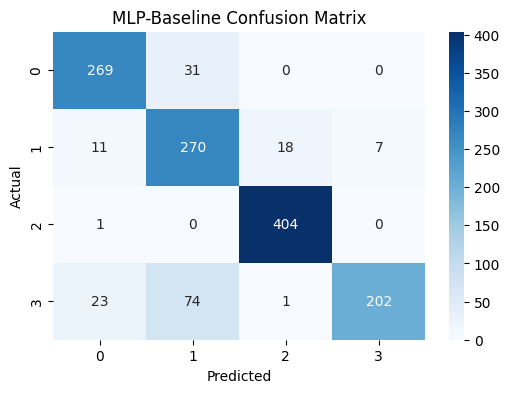


🚀 Training Deep-MLP ...
Epoch 1/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 11s 69ms/step - accuracy: 0.7811 - loss: 0.6155 - val_accuracy: 0.6737 - val_loss: 1.7148
Epoch 2/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9560 - loss: 0.1305 - val_accuracy: 0.8600 - val_loss: 0.4909
Epoch 3/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9664 - loss: 0.0894 - val_accuracy: 0.7515 - val_loss: 0.9028
Epoch 4/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9859 - loss: 0.0414 - val_accuracy: 0.7944 - val_loss: 0.8243
Epoch 5/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9924 - loss: 0.0263 - val_accuracy: 0.6579 - val_loss: 2.0052
Epoch 6/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9886 - loss: 0.0325 - val_accuracy: 0.6877 - val_loss: 2.0013
Epoch 7/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9916 - loss: 0.0255 - val_accuracy: 0.7760 - val_loss: 1.2462
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step

🔹 Deep-MLP Results:
Accuracy: 0.8535 | Preci

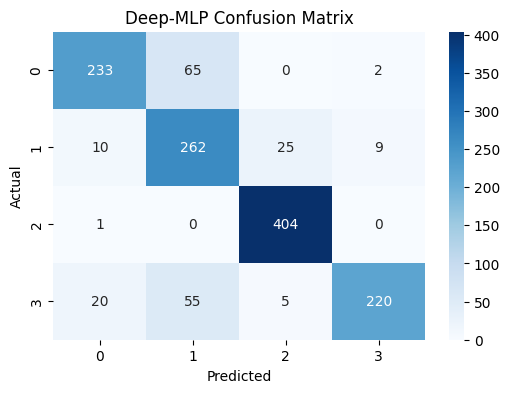


🚀 Training Autoencoder-Classifier ...
Epoch 1/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.7634 - loss: 0.7201 - val_accuracy: 0.8206 - val_loss: 0.4776
Epoch 2/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9717 - loss: 0.0715 - val_accuracy: 0.7673 - val_loss: 0.6567
Epoch 3/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9930 - loss: 0.0211 - val_accuracy: 0.6588 - val_loss: 1.2792
Epoch 4/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9941 - loss: 0.0160 - val_accuracy: 0.8443 - val_loss: 0.7016
Epoch 5/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9950 - loss: 0.0168 - val_accuracy: 0.8285 - val_loss: 0.6974
Epoch 6/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9924 - loss: 0.0170 - val_accuracy: 0.6588 - val_loss: 1.4506
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

🔹 Autoencoder-Classifier Results:
Accuracy: 0.8543 | Precision: 0.8698 | Recall: 0.8543 | F1: 0.8541 | MCC: 0.8095


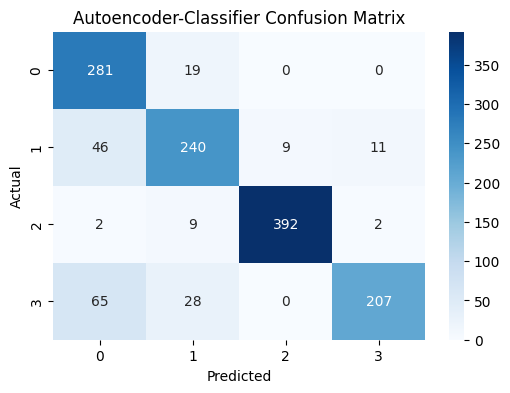


Deep Learning Model Performance Summary:
                    Model  Accuracy  Precision    Recall        F1       MCC
0            MLP-Baseline  0.873379   0.886759  0.873379  0.872001  0.834200
1                Deep-MLP  0.853547   0.867556  0.853547  0.853969  0.807001
2  Autoencoder-Classifier  0.854310   0.869756  0.854310  0.854094  0.809471

🧩 Ensemble Fusion Results
Accuracy: 0.8909 | Precision: 0.8982 | Recall: 0.8909 | F1: 0.8901 | MCC: 0.8559


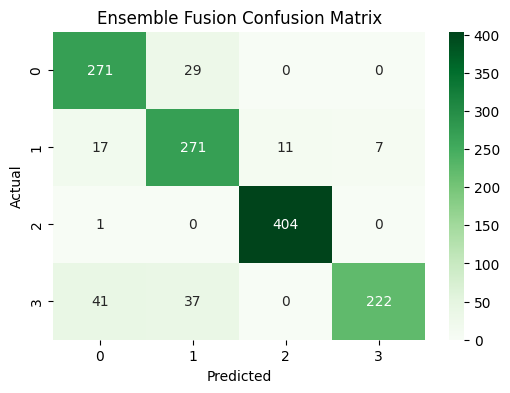

In [6]:
# ======================================================
# Phase 2: Deep Learning Fusion (Cleaned & Optimized)
# ======================================================
import numpy as np
import tensorflow as tf
import os, warnings
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score, matthews_corrcoef
)

# ======================================================
# ⚙️ Logging and Warnings Control
# ======================================================
warnings.filterwarnings("ignore", category=UserWarning, module='keras')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'     # Suppress TensorFlow info/warnings
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'    # Disable oneDNN logs
tf.get_logger().setLevel('ERROR')
tf.autograph.set_verbosity(0)

# ======================================================
# 🧠 GPU Configuration — Use 1st GPU (avoid MirroredStrategy conflict)
# ======================================================
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.set_visible_devices(gpus[0], 'GPU')  # Use first GPU only
        tf.config.experimental.set_memory_growth(gpus[0], True)
        print(f"✅ Using single GPU: {gpus[0].name}")
    except Exception as e:
        print(f"⚠️ GPU config error. Defaulting to CPU. Error: {e}")
else:
    print("⚠️ No GPU detected. Running on CPU.")

# ======================================================
# 🧩 Load Precomputed Feature Embeddings
# ======================================================
resnet_train = np.load("/kaggle/input/embeddings/Embeddings/resnet18/resnet_train_features.npy")
resnet_test  = np.load("/kaggle/input/embeddings/Embeddings/resnet18/resnet_test_features.npy")

vgg_train = np.load("/kaggle/input/embeddings/Embeddings/vgg16/vgg_train_features.npy")
vgg_test  = np.load("/kaggle/input/embeddings/Embeddings/vgg16/vgg_test_features.npy")

eff_train = np.load("/kaggle/input/embeddings/Embeddings/EfficientNet-BO/efficientnet_train_features.npy")
eff_test  = np.load("/kaggle/input/embeddings/Embeddings/EfficientNet-BO/efficientnet_test_features.npy")

train_labels = np.load("/kaggle/input/embeddings/Embeddings/resnet18/resnet_train_labels.npy")
test_labels  = np.load("/kaggle/input/embeddings/Embeddings/resnet18/resnet_test_labels.npy")

# ======================================================
# ✅ Align Dataset Lengths (safety for concat)
# ======================================================
min_train = min(resnet_train.shape[0], vgg_train.shape[0], eff_train.shape[0])
min_test  = min(resnet_test.shape[0], vgg_test.shape[0], eff_test.shape[0])

resnet_train, vgg_train, eff_train, train_labels = (
    resnet_train[:min_train], vgg_train[:min_train],
    eff_train[:min_train], train_labels[:min_train]
)
resnet_test, vgg_test, eff_test, test_labels = (
    resnet_test[:min_test], vgg_test[:min_test],
    eff_test[:min_test], test_labels[:min_test]
)

# ======================================================
# 🔗 Feature Fusion (Concatenate Embeddings)
# ======================================================
X_train = np.concatenate((resnet_train, vgg_train, eff_train), axis=1)
X_test  = np.concatenate((resnet_test, vgg_test, eff_test), axis=1)
num_classes = len(np.unique(train_labels))

print(f"✅ Combined Train: {X_train.shape}, Test: {X_test.shape}, Classes: {num_classes}")

# ======================================================
# 🧱 Deep Learning Models (no warnings)
# ======================================================
def build_mlp_baseline(input_dim, num_classes):
    model = Sequential([
        Input(shape=(input_dim,)),                  # ✅ clean input layer
        Dense(1024, activation='relu'),
        BatchNormalization(),
        Dropout(0.4),
        Dense(512, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])
    return model

def build_deep_mlp(input_dim, num_classes):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(2048, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(1024, activation='relu'),
        BatchNormalization(),
        Dropout(0.4),
        Dense(512, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(256, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])
    return model

def build_autoencoder_classifier(input_dim, num_classes):
    inp = Input(shape=(input_dim,))
    x = Dense(512, activation='relu')(inp)
    x = Dense(128, activation='relu')(x)
    x = Dense(512, activation='relu')(x)
    out = Dense(num_classes, activation='softmax')(x)
    model = Model(inp, out)
    return model

# ======================================================
# ⚡ Training & Evaluation Function
# ======================================================
def train_and_evaluate(model, name, X_train, y_train, X_test, y_test, epochs=30, batch_size=64):
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    print(f"\n🚀 Training {name} ...")
    history = model.fit(
        X_train, y_train, validation_split=0.2,
        epochs=epochs, batch_size=batch_size,
        callbacks=[es], verbose=1
    )

    # Predictions
    y_pred = np.argmax(model.predict(X_test), axis=1)

    # Metrics
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    mcc  = matthews_corrcoef(y_test, y_pred)

    print(f"\n🔹 {name} Results:")
    print(f"Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f} | MCC: {mcc:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return model, {"Model": name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1, "MCC": mcc}, y_pred

# ======================================================
# 🚀 Train All Models (Clean Single-GPU)
# ======================================================
models_info = [
    ("MLP-Baseline", build_mlp_baseline(X_train.shape[1], num_classes)),
    ("Deep-MLP", build_deep_mlp(X_train.shape[1], num_classes)),
    ("Autoencoder-Classifier", build_autoencoder_classifier(X_train.shape[1], num_classes))
]

results, all_preds = [], []
for name, model in models_info:
    model, metrics, preds = train_and_evaluate(model, name, X_train, train_labels, X_test, test_labels)
    results.append(metrics)
    all_preds.append(preds)

# ======================================================
# 📊 Performance Summary
# ======================================================
results_df = pd.DataFrame(results)
print("\nDeep Learning Model Performance Summary:")
print(results_df)

# ======================================================
# 🧠 Ensemble Fusion (Majority Voting)
# ======================================================
ensemble_preds = np.array(all_preds)
final_preds = np.apply_along_axis(lambda x: np.bincount(x).argmax(), axis=0, arr=ensemble_preds)

ens_acc  = accuracy_score(test_labels, final_preds)
ens_prec = precision_score(test_labels, final_preds, average='weighted', zero_division=0)
ens_rec  = recall_score(test_labels, final_preds, average='weighted', zero_division=0)
ens_f1   = f1_score(test_labels, final_preds, average='weighted', zero_division=0)
ens_mcc  = matthews_corrcoef(test_labels, final_preds)

print("\n🧩 Ensemble Fusion Results")
print(f"Accuracy: {ens_acc:.4f} | Precision: {ens_prec:.4f} | Recall: {ens_rec:.4f} | F1: {ens_f1:.4f} | MCC: {ens_mcc:.4f}")

cm = confusion_matrix(test_labels, final_preds)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.title("Ensemble Fusion Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

⚠️ GPU config error. Defaulting to CPU. Error: Visible devices cannot be modified after being initialized
✅ Combined Train: (5712, 26880), Test: (1311, 26880), Classes: 4

🚀 Training MLP-Baseline ...
Epoch 1/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 8s 46ms/step - accuracy: 0.8280 - loss: 0.5743 - val_accuracy: 0.9676 - val_loss: 0.0841
Epoch 2/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9697 - loss: 0.0934 - val_accuracy: 0.7962 - val_loss: 0.6861
Epoch 3/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9838 - loss: 0.0455 - val_accuracy: 0.4348 - val_loss: 3.2073
Epoch 4/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9941 - loss: 0.0208 - val_accuracy: 0.8198 - val_loss: 0.6591
Epoch 5/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9930 - loss: 0.0174 - val_accuracy: 0.6780 - val_loss: 1.2380
Epoch 6/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9965 - loss: 0.0127 - val_accuracy: 0.6780 - val_loss: 1.2295
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step

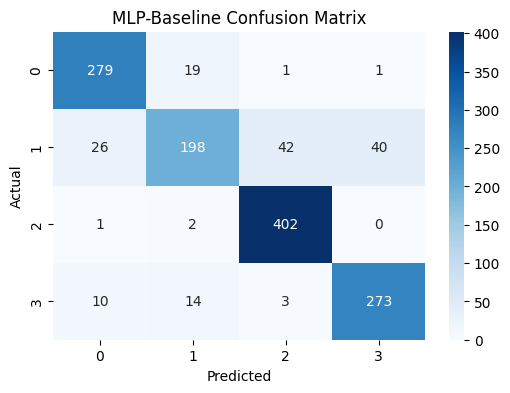


🚀 Training Deep-MLP ...
Epoch 1/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 11s 67ms/step - accuracy: 0.7816 - loss: 0.6152 - val_accuracy: 0.6334 - val_loss: 1.7887
Epoch 2/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9560 - loss: 0.1213 - val_accuracy: 0.4864 - val_loss: 2.7936
Epoch 3/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9783 - loss: 0.0597 - val_accuracy: 0.6378 - val_loss: 1.9934
Epoch 4/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9862 - loss: 0.0398 - val_accuracy: 0.7778 - val_loss: 0.9762
Epoch 5/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9885 - loss: 0.0430 - val_accuracy: 0.5004 - val_loss: 2.9910
Epoch 6/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9942 - loss: 0.0185 - val_accuracy: 0.6737 - val_loss: 2.1814
Epoch 7/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9945 - loss: 0.0172 - val_accuracy: 0.6282 - val_loss: 2.3095
Epoch 8/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9972 - loss: 0.0067 

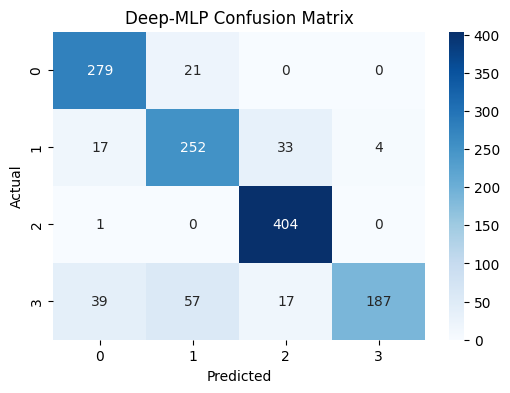


🚀 Training Autoencoder-Classifier ...
Epoch 1/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.7715 - loss: 0.7682 - val_accuracy: 0.4033 - val_loss: 2.2331
Epoch 2/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9819 - loss: 0.0580 - val_accuracy: 0.6203 - val_loss: 1.5674
Epoch 3/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9731 - loss: 0.0800 - val_accuracy: 0.5818 - val_loss: 1.9567
Epoch 4/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9935 - loss: 0.0131 - val_accuracy: 0.7550 - val_loss: 1.0703
Epoch 5/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9933 - loss: 0.0206 - val_accuracy: 0.6640 - val_loss: 1.3877
Epoch 6/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9989 - loss: 0.0028 - val_accuracy: 0.7927 - val_loss: 0.8842
Epoch 7/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9999 - loss: 9.5972e-04 - val_accuracy: 0.4716 - val_loss: 4.3836
Epoch 8/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9990 - lo

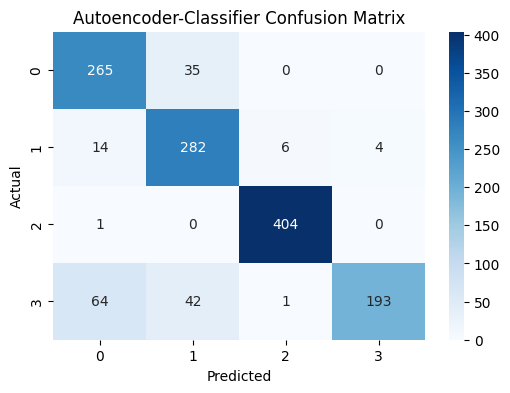


Deep Learning Model Performance Summary:
                    Model  Accuracy  Precision    Recall        F1       MCC
0            MLP-Baseline  0.878719   0.876545  0.878719  0.873440  0.839288
1                Deep-MLP  0.855835   0.867196  0.855835  0.850622  0.810960
2  Autoencoder-Classifier  0.872616   0.887478  0.872616  0.869906  0.834003

🧩 Ensemble Fusion Results
Accuracy: 0.8810 | Precision: 0.8910 | Recall: 0.8810 | F1: 0.8790 | MCC: 0.8437


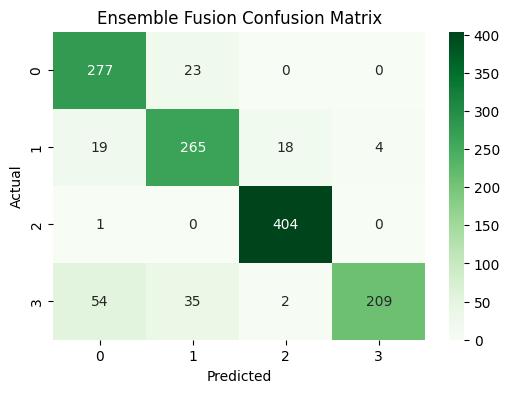

In [7]:
# ======================================================
# Phase 2: Deep Learning Fusion (Cleaned & Optimized)
# ======================================================
import numpy as np
import tensorflow as tf
import os, warnings
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score, matthews_corrcoef
)

# ======================================================
# ⚙️ Logging and Warnings Control
# ======================================================
warnings.filterwarnings("ignore", category=UserWarning, module='keras')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'     # Suppress TensorFlow info/warnings
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'    # Disable oneDNN logs
tf.get_logger().setLevel('ERROR')
tf.autograph.set_verbosity(0)

# ======================================================
# 🧠 GPU Configuration — Use 1st GPU (avoid MirroredStrategy conflict)
# ======================================================
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.set_visible_devices(gpus[0], 'GPU')  # Use first GPU only
        tf.config.experimental.set_memory_growth(gpus[0], True)
        print(f"✅ Using single GPU: {gpus[0].name}")
    except Exception as e:
        print(f"⚠️ GPU config error. Defaulting to CPU. Error: {e}")
else:
    print("⚠️ No GPU detected. Running on CPU.")

# ======================================================
# 🧩 Load Precomputed Feature Embeddings
# ======================================================
resnet_train = np.load("/kaggle/input/embeddings/Embeddings/resnet18/resnet_train_features.npy")
resnet_test  = np.load("/kaggle/input/embeddings/Embeddings/resnet18/resnet_test_features.npy")

vgg_train = np.load("/kaggle/input/embeddings/Embeddings/vgg16/vgg_train_features.npy")
vgg_test  = np.load("/kaggle/input/embeddings/Embeddings/vgg16/vgg_test_features.npy")

eff_train = np.load("/kaggle/input/embeddings/Embeddings/EfficientNet-BO/efficientnet_train_features.npy")
eff_test  = np.load("/kaggle/input/embeddings/Embeddings/EfficientNet-BO/efficientnet_test_features.npy")

train_labels = np.load("/kaggle/input/embeddings/Embeddings/resnet18/resnet_train_labels.npy")
test_labels  = np.load("/kaggle/input/embeddings/Embeddings/resnet18/resnet_test_labels.npy")

# ======================================================
# ✅ Align Dataset Lengths (safety for concat)
# ======================================================
min_train = min(resnet_train.shape[0], vgg_train.shape[0], eff_train.shape[0])
min_test  = min(resnet_test.shape[0], vgg_test.shape[0], eff_test.shape[0])

resnet_train, vgg_train, eff_train, train_labels = (
    resnet_train[:min_train], vgg_train[:min_train],
    eff_train[:min_train], train_labels[:min_train]
)
resnet_test, vgg_test, eff_test, test_labels = (
    resnet_test[:min_test], vgg_test[:min_test],
    eff_test[:min_test], test_labels[:min_test]
)

# ======================================================
# 🔗 Feature Fusion (Concatenate Embeddings)
# ======================================================
X_train = np.concatenate((resnet_train, vgg_train, eff_train), axis=1)
X_test  = np.concatenate((resnet_test, vgg_test, eff_test), axis=1)
num_classes = len(np.unique(train_labels))

print(f"✅ Combined Train: {X_train.shape}, Test: {X_test.shape}, Classes: {num_classes}")

# ======================================================
# 🧱 Deep Learning Models (no warnings)
# ======================================================
def build_mlp_baseline(input_dim, num_classes):
    model = Sequential([
        Input(shape=(input_dim,)),                  # ✅ clean input layer
        Dense(1024, activation='relu'),
        BatchNormalization(),
        Dropout(0.4),
        Dense(512, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])
    return model

def build_deep_mlp(input_dim, num_classes):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(2048, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(1024, activation='relu'),
        BatchNormalization(),
        Dropout(0.4),
        Dense(512, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(256, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])
    return model

def build_autoencoder_classifier(input_dim, num_classes):
    inp = Input(shape=(input_dim,))
    x = Dense(512, activation='relu')(inp)
    x = Dense(128, activation='relu')(x)
    x = Dense(512, activation='relu')(x)
    out = Dense(num_classes, activation='softmax')(x)
    model = Model(inp, out)
    return model

# ======================================================
# ⚡ Training & Evaluation Function
# ======================================================
def train_and_evaluate(model, name, X_train, y_train, X_test, y_test, epochs=30, batch_size=64):
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    print(f"\n🚀 Training {name} ...")
    history = model.fit(
        X_train, y_train, validation_split=0.2,
        epochs=epochs, batch_size=batch_size,
        callbacks=[es], verbose=1
    )

    # Predictions
    y_pred = np.argmax(model.predict(X_test), axis=1)

    # Metrics
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    mcc  = matthews_corrcoef(y_test, y_pred)

    print(f"\n🔹 {name} Results:")
    print(f"Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f} | MCC: {mcc:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return model, {"Model": name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1, "MCC": mcc}, y_pred

# ======================================================
# 🚀 Train All Models (Clean Single-GPU)
# ======================================================
models_info = [
    ("MLP-Baseline", build_mlp_baseline(X_train.shape[1], num_classes)),
    ("Deep-MLP", build_deep_mlp(X_train.shape[1], num_classes)),
    ("Autoencoder-Classifier", build_autoencoder_classifier(X_train.shape[1], num_classes))
]

results, all_preds = [], []
for name, model in models_info:
    model, metrics, preds = train_and_evaluate(model, name, X_train, train_labels, X_test, test_labels)
    results.append(metrics)
    all_preds.append(preds)

# ======================================================
# 📊 Performance Summary
# ======================================================
results_df = pd.DataFrame(results)
print("\nDeep Learning Model Performance Summary:")
print(results_df)

# ======================================================
# 🧠 Ensemble Fusion (Majority Voting)
# ======================================================
ensemble_preds = np.array(all_preds)
final_preds = np.apply_along_axis(lambda x: np.bincount(x).argmax(), axis=0, arr=ensemble_preds)

ens_acc  = accuracy_score(test_labels, final_preds)
ens_prec = precision_score(test_labels, final_preds, average='weighted', zero_division=0)
ens_rec  = recall_score(test_labels, final_preds, average='weighted', zero_division=0)
ens_f1   = f1_score(test_labels, final_preds, average='weighted', zero_division=0)
ens_mcc  = matthews_corrcoef(test_labels, final_preds)

print("\n🧩 Ensemble Fusion Results")
print(f"Accuracy: {ens_acc:.4f} | Precision: {ens_prec:.4f} | Recall: {ens_rec:.4f} | F1: {ens_f1:.4f} | MCC: {ens_mcc:.4f}")

cm = confusion_matrix(test_labels, final_preds)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.title("Ensemble Fusion Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# ======================================================
# Phase 2: Deep Learning Fusion (Cleaned & Optimized)
# ======================================================
import numpy as np
import tensorflow as tf
import os, warnings
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score, matthews_corrcoef
)

# ======================================================
# ⚙️ Logging and Warnings Control
# ======================================================
warnings.filterwarnings("ignore", category=UserWarning, module='keras')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'     # Suppress TensorFlow info/warnings
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'    # Disable oneDNN logs
tf.get_logger().setLevel('ERROR')
tf.autograph.set_verbosity(0)

# ======================================================
# 🧠 GPU Configuration — Use 1st GPU (avoid MirroredStrategy conflict)
# ======================================================
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.set_visible_devices(gpus[0], 'GPU')  # Use first GPU only
        tf.config.experimental.set_memory_growth(gpus[0], True)
        print(f"✅ Using single GPU: {gpus[0].name}")
    except Exception as e:
        print(f"⚠️ GPU config error. Defaulting to CPU. Error: {e}")
else:
    print("⚠️ No GPU detected. Running on CPU.")

# ======================================================
# 🧩 Load Precomputed Feature Embeddings
# ======================================================
resnet_train = np.load("/kaggle/input/embeddings/Embeddings/resnet18/resnet_train_features.npy")
resnet_test  = np.load("/kaggle/input/embeddings/Embeddings/resnet18/resnet_test_features.npy")

vgg_train = np.load("/kaggle/input/embeddings/Embeddings/vgg16/vgg_train_features.npy")
vgg_test  = np.load("/kaggle/input/embeddings/Embeddings/vgg16/vgg_test_features.npy")

eff_train = np.load("/kaggle/input/embeddings/Embeddings/EfficientNet-BO/efficientnet_train_features.npy")
eff_test  = np.load("/kaggle/input/embeddings/Embeddings/EfficientNet-BO/efficientnet_test_features.npy")

train_labels = np.load("/kaggle/input/embeddings/Embeddings/resnet18/resnet_train_labels.npy")
test_labels  = np.load("/kaggle/input/embeddings/Embeddings/resnet18/resnet_test_labels.npy")

# ======================================================
# ✅ Align Dataset Lengths (safety for concat)
# ======================================================
min_train = min(resnet_train.shape[0], vgg_train.shape[0], eff_train.shape[0])
min_test  = min(resnet_test.shape[0], vgg_test.shape[0], eff_test.shape[0])

resnet_train, vgg_train, eff_train, train_labels = (
    resnet_train[:min_train], vgg_train[:min_train],
    eff_train[:min_train], train_labels[:min_train]
)
resnet_test, vgg_test, eff_test, test_labels = (
    resnet_test[:min_test], vgg_test[:min_test],
    eff_test[:min_test], test_labels[:min_test]
)

# ======================================================
# 🔗 Feature Fusion (Concatenate Embeddings)
# ======================================================
X_train = np.concatenate((resnet_train, vgg_train, eff_train), axis=1)
X_test  = np.concatenate((resnet_test, vgg_test, eff_test), axis=1)
num_classes = len(np.unique(train_labels))

print(f"✅ Combined Train: {X_train.shape}, Test: {X_test.shape}, Classes: {num_classes}")

# ======================================================
# 🧱 Deep Learning Models (no warnings)
# ======================================================
def build_mlp_baseline(input_dim, num_classes):
    model = Sequential([
        Input(shape=(input_dim,)),                  # ✅ clean input layer
        Dense(1024, activation='relu'),
        BatchNormalization(),
        Dropout(0.4),
        Dense(512, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])
    return model

def build_deep_mlp(input_dim, num_classes):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(2048, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(1024, activation='relu'),
        BatchNormalization(),
        Dropout(0.4),
        Dense(512, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(256, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])
    return model

def build_autoencoder_classifier(input_dim, num_classes):
    inp = Input(shape=(input_dim,))
    x = Dense(512, activation='relu')(inp)
    x = Dense(128, activation='relu')(x)
    x = Dense(512, activation='relu')(x)
    out = Dense(num_classes, activation='softmax')(x)
    model = Model(inp, out)
    return model

def build_lstm_model(input_dim, num_classes):
    model = models.Sequential([
        layers.Input(shape=(input_dim, 1)),
        layers.LSTM(128, return_sequences=True),
        layers.LSTM(64),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

# ======================================================
# ⚡ Training & Evaluation Function
# ======================================================
def train_and_evaluate(model, name, X_train, y_train, X_test, y_test, epochs=30, batch_size=64):
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    print(f"\n🚀 Training {name} ...")
    history = model.fit(
        X_train, y_train, validation_split=0.2,
        epochs=epochs, batch_size=batch_size,
        callbacks=[es], verbose=1
    )

    # Predictions
    y_pred = np.argmax(model.predict(X_test), axis=1)

    # Metrics
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    mcc  = matthews_corrcoef(y_test, y_pred)

    print(f"\n🔹 {name} Results:")
    print(f"Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f} | MCC: {mcc:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return model, {"Model": name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1, "MCC": mcc}, y_pred

# ======================================================
# 🚀 Train All Models (Clean Single-GPU)
# ======================================================
models_info = [
    ("MLP-Baseline", build_mlp_baseline(X_train.shape[1], num_classes)),
    ("Deep-MLP", build_deep_mlp(X_train.shape[1], num_classes)),
    ("Autoencoder-Classifier", build_autoencoder_classifier(X_train.shape[1], num_classes)),
    ('LSTM', build_lstm_model(X_train.shape[1], num_classes))
]

results, all_preds = [], []
for name, model in models_info:
    model, metrics, preds = train_and_evaluate(model, name, X_train, train_labels, X_test, test_labels)
    results.append(metrics)
    all_preds.append(preds)

# ======================================================
# 📊 Performance Summary
# ======================================================
results_df = pd.DataFrame(results)
print("\nDeep Learning Model Performance Summary:")
print(results_df)

# ======================================================
# 🧠 Ensemble Fusion (Majority Voting)
# ======================================================
ensemble_preds = np.array(all_preds)
final_preds = np.apply_along_axis(lambda x: np.bincount(x).argmax(), axis=0, arr=ensemble_preds)

ens_acc  = accuracy_score(test_labels, final_preds)
ens_prec = precision_score(test_labels, final_preds, average='weighted', zero_division=0)
ens_rec  = recall_score(test_labels, final_preds, average='weighted', zero_division=0)
ens_f1   = f1_score(test_labels, final_preds, average='weighted', zero_division=0)
ens_mcc  = matthews_corrcoef(test_labels, final_preds)

print("\n🧩 Ensemble Fusion Results")
print(f"Accuracy: {ens_acc:.4f} | Precision: {ens_prec:.4f} | Recall: {ens_rec:.4f} | F1: {ens_f1:.4f} | MCC: {ens_mcc:.4f}")

cm = confusion_matrix(test_labels, final_preds)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.title("Ensemble Fusion Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# more Enhancement dobby..!

In [9]:
# ===============================================================
# 🧠 Phase 2: Combined Deep Learning Fusion (Kaggle T4 ×2 Ready)
# ===============================================================

import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef
)
import warnings, os

# ===============================================================
# ⚙️ Logging and GPU Configuration
# ===============================================================
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
tf.get_logger().setLevel('ERROR')

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.set_visible_devices(gpus, 'GPU')
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✅ Using GPUs: {[g.name for g in gpus]}")
    except Exception as e:
        print(f"⚠️ GPU configuration failed: {e}")
else:
    print("⚠️ No GPU detected, running on CPU.")

# ===============================================================
# 1️⃣ Load and Combine Embeddings
# ===============================================================
resnet_train = np.load("/kaggle/input/embeddings/Embeddings/resnet18/resnet_train_features.npy")
resnet_test  = np.load("/kaggle/input/embeddings/Embeddings/resnet18/resnet_test_features.npy")

vgg_train = np.load("/kaggle/input/embeddings/Embeddings/vgg16/vgg_train_features.npy")
vgg_test  = np.load("/kaggle/input/embeddings/Embeddings/vgg16/vgg_test_features.npy")

eff_train = np.load("/kaggle/input/embeddings/Embeddings/EfficientNet-BO/efficientnet_train_features.npy")
eff_test  = np.load("/kaggle/input/embeddings/Embeddings/EfficientNet-BO/efficientnet_test_features.npy")

train_labels = np.load("/kaggle/input/embeddings/Embeddings/resnet18/resnet_train_labels.npy")
test_labels  = np.load("/kaggle/input/embeddings/Embeddings/resnet18/resnet_test_labels.npy")

# Align dataset lengths
min_train = min(resnet_train.shape[0], vgg_train.shape[0], eff_train.shape[0])
min_test  = min(resnet_test.shape[0], vgg_test.shape[0], eff_test.shape[0])

resnet_train, vgg_train, eff_train, train_labels = (
    resnet_train[:min_train], vgg_train[:min_train],
    eff_train[:min_train], train_labels[:min_train]
)
resnet_test, vgg_test, eff_test, test_labels = (
    resnet_test[:min_test], vgg_test[:min_test],
    eff_test[:min_test], test_labels[:min_test]
)

# Combine embeddings
X_train = np.concatenate([resnet_train, vgg_train, eff_train], axis=1)
X_test = np.concatenate([resnet_test, vgg_test, eff_test], axis=1)

# Normalize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ===============================================================
# 2️⃣ Light Data Augmentation (Noise Injection)
# ===============================================================
noise_factor = 0.01
X_train_noisy = X_train + noise_factor * np.random.randn(*X_train.shape)
X_train = np.vstack([X_train, X_train_noisy])
y_train = np.hstack([train_labels, train_labels])
y_test = test_labels

print(f"✅ Combined Train: {X_train.shape}, Test: {X_test.shape}")

# ===============================================================
# 3️⃣ Model Architectures (Dense, CNN, LSTM)
# ===============================================================

def build_dense_model(input_dim, num_classes):
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(1024), layers.BatchNormalization(), layers.ReLU(), layers.Dropout(0.4),
        layers.Dense(512), layers.BatchNormalization(), layers.ReLU(), layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

def build_cnn_model(input_dim, num_classes):
    model = models.Sequential([
        layers.Input(shape=(input_dim, 1)),
        layers.Conv1D(128, 5, activation='relu', padding='same'),
        layers.MaxPooling1D(2),
        layers.Conv1D(64, 3, activation='relu', padding='same'),
        layers.GlobalAveragePooling1D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

def build_lstm_model(input_dim, num_classes):
    model = models.Sequential([
        layers.Input(shape=(input_dim, 1)),
        layers.LSTM(128, return_sequences=True),
        layers.LSTM(64),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

# ===============================================================
# 4️⃣ Training Utility Function
# ===============================================================
def compile_and_train(model, X_train, y_train, name):
    lr_schedule = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)
    early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    model.compile(optimizer=optimizers.Adam(learning_rate=1e-4),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    if len(X_train.shape) == 2 and len(model.input_shape) == 3:
        X_train = np.expand_dims(X_train, -1)
    print(f"\n🚀 Training {name} ...")
    model.fit(X_train, y_train, validation_split=0.2, epochs=30, batch_size=128,
              callbacks=[lr_schedule, early_stop], verbose=1)
    return model

# ===============================================================
# 5️⃣ Train Models (Dense, CNN, LSTM)
# ===============================================================
input_dim = X_train.shape[1]
num_classes = len(np.unique(y_train))

dense_model = compile_and_train(build_dense_model(input_dim, num_classes), X_train, y_train, "Dense-MLP")
cnn_model = compile_and_train(build_cnn_model(input_dim, num_classes), np.expand_dims(X_train, -1), y_train, "CNN-1D")
lstm_model = compile_and_train(build_lstm_model(input_dim, num_classes), np.expand_dims(X_train, -1), y_train, "LSTM-Hybrid")

# ===============================================================
# 6️⃣ Ensemble Predictions (Soft Voting)
# ===============================================================
X_test_exp = np.expand_dims(X_test, -1)
pred_dense = dense_model.predict(X_test)
pred_cnn   = cnn_model.predict(X_test_exp)
pred_lstm  = lstm_model.predict(X_test_exp)

ensemble_pred = (pred_dense + pred_cnn + pred_lstm) / 3.0
final_preds = np.argmax(ensemble_pred, axis=1)

# ===============================================================
# 7️⃣ Evaluation Metrics
# ===============================================================
metrics = {
    "Accuracy": accuracy_score(y_test, final_preds),
    "Precision": precision_score(y_test, final_preds, average='weighted', zero_division=0),
    "Recall": recall_score(y_test, final_preds, average='weighted', zero_division=0),
    "F1-score": f1_score(y_test, final_preds, average='weighted', zero_division=0),
    "MCC": matthews_corrcoef(y_test, final_preds)
}

print("\n📊 Final Ensemble Performance:")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

print("\nPhase 2 Fusion Completed Successfully!")

✅ Using GPUs: ['/physical_device:GPU:0', '/physical_device:GPU:1']
✅ Combined Train: (11424, 26880), Test: (1311, 26880)

🚀 Training Dense-MLP ...
Epoch 1/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 10s 71ms/step - accuracy: 0.8169 - loss: 0.4977 - val_accuracy: 1.0000 - val_loss: 0.0036 - learning_rate: 1.0000e-04
Epoch 2/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9977 - loss: 0.0262 - val_accuracy: 1.0000 - val_loss: 0.0013 - learning_rate: 1.0000e-04
Epoch 3/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9998 - loss: 0.0107 - val_accuracy: 1.0000 - val_loss: 8.1210e-04 - learning_rate: 1.0000e-04
Epoch 4/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9999 - loss: 0.0060 - val_accuracy: 1.0000 - val_loss: 5.8158e-04 - learning_rate: 1.0000e-04
Epoch 5/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9999 - loss: 0.0037 - val_accuracy: 1.0000 - val_loss: 4.2586e-04 - learning_rate: 1.0000e-04
Epoch 6/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.

UnknownError: Graph execution error:

Detected at node StatefulPartitionedCall defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/usr/local/lib/python3.11/dist-packages/colab_kernel_launcher.py", line 37, in <module>

  File "/usr/local/lib/python3.11/dist-packages/traitlets/config/application.py", line 992, in launch_instance

  File "/usr/local/lib/python3.11/dist-packages/ipykernel/kernelapp.py", line 712, in start

  File "/usr/local/lib/python3.11/dist-packages/tornado/platform/asyncio.py", line 211, in start

  File "/usr/lib/python3.11/asyncio/base_events.py", line 608, in run_forever

  File "/usr/lib/python3.11/asyncio/base_events.py", line 1936, in _run_once

  File "/usr/lib/python3.11/asyncio/events.py", line 84, in _run

  File "/usr/local/lib/python3.11/dist-packages/ipykernel/kernelbase.py", line 510, in dispatch_queue

  File "/usr/local/lib/python3.11/dist-packages/ipyk

2025-11-03 03:27:27.223450: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762140447.654855      37 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762140447.773273      37 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


✅ Using GPU: /physical_device:GPU:0

📥 Loading feature embeddings...
✅ Combined Features — Train: (5712, 26880), Test: (1311, 26880), Classes: 4


I0000 00:00:1762140470.380844      37 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5



🚀 Training MLP-Baseline ...
Epoch 1/30


I0000 00:00:1762140476.475158      97 service.cc:148] XLA service 0x7e42e8003aa0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1762140476.477266      97 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1762140476.851544      97 cuda_dnn.cc:529] Loaded cuDNN version 90300


19/72 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7107 - loss: 0.9113

I0000 00:00:1762140479.132929      97 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


72/72 ━━━━━━━━━━━━━━━━━━━━ 10s 59ms/step - accuracy: 0.8256 - loss: 0.5523 - val_accuracy: 0.7122 - val_loss: 1.0950
Epoch 2/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9739 - loss: 0.0743 - val_accuracy: 0.7647 - val_loss: 0.7897
Epoch 3/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9871 - loss: 0.0313 - val_accuracy: 0.7620 - val_loss: 0.8660
Epoch 4/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9879 - loss: 0.0305 - val_accuracy: 0.6807 - val_loss: 1.2810
Epoch 5/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9903 - loss: 0.0257 - val_accuracy: 0.7559 - val_loss: 0.8804
Epoch 6/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9917 - loss: 0.0252 - val_accuracy: 0.6518 - val_loss: 1.3258
Epoch 7/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9977 - loss: 0.0090 - val_accuracy: 0.6780 - val_loss: 1.2288


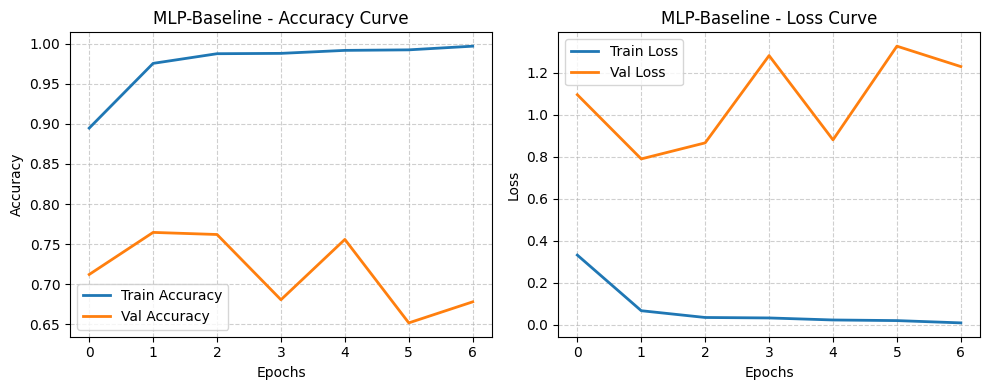

41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step

🔹 MLP-Baseline Results:
Accuracy: 0.8360 | Precision: 0.8648 | Recall: 0.8360 | F1: 0.8353 | MCC: 0.7884


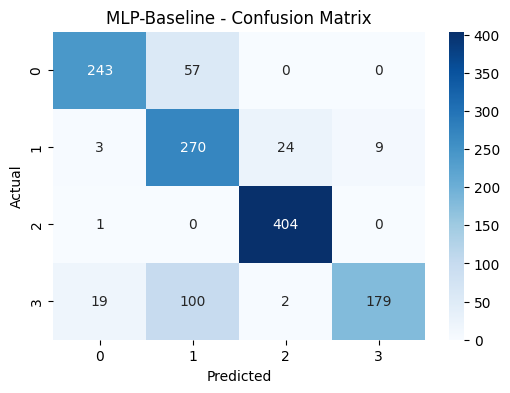


🚀 Training Deep-MLP ...
Epoch 1/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 13s 85ms/step - accuracy: 0.7730 - loss: 0.5911 - val_accuracy: 0.7043 - val_loss: 1.1409
Epoch 2/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9600 - loss: 0.1047 - val_accuracy: 0.8731 - val_loss: 0.6708
Epoch 3/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9759 - loss: 0.0745 - val_accuracy: 0.6614 - val_loss: 1.2857
Epoch 4/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9889 - loss: 0.0338 - val_accuracy: 0.6772 - val_loss: 1.5978
Epoch 5/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9801 - loss: 0.0613 - val_accuracy: 0.8355 - val_loss: 0.5434
Epoch 6/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9912 - loss: 0.0191 - val_accuracy: 0.8556 - val_loss: 0.5736
Epoch 7/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9939 - loss: 0.0247 - val_accuracy: 0.9003 - val_loss: 0.4199
Epoch 8/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9899 - loss: 0.0272 

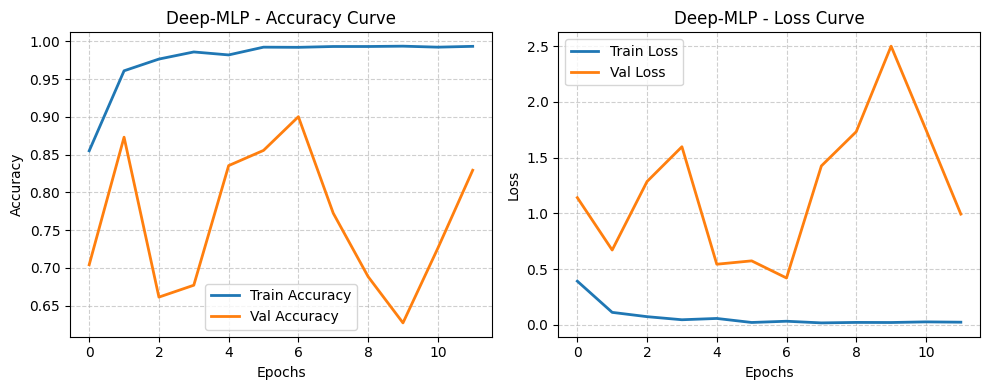

41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step

🔹 Deep-MLP Results:
Accuracy: 0.8795 | Precision: 0.8968 | Recall: 0.8795 | F1: 0.8812 | MCC: 0.8428


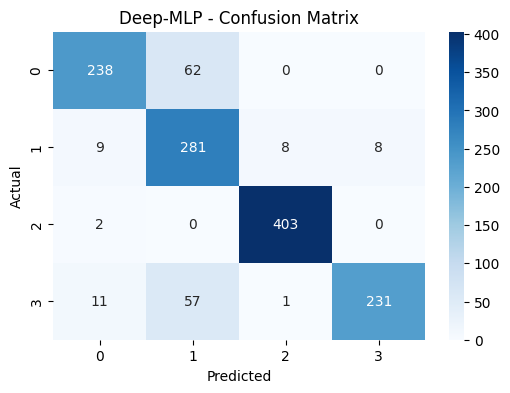


🚀 Training Autoencoder-Classifier ...
Epoch 1/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.7389 - loss: 0.9602 - val_accuracy: 0.6045 - val_loss: 1.1210
Epoch 2/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9861 - loss: 0.0445 - val_accuracy: 0.8661 - val_loss: 0.4428
Epoch 3/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9933 - loss: 0.0224 - val_accuracy: 0.8031 - val_loss: 0.7126
Epoch 4/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9972 - loss: 0.0066 - val_accuracy: 0.6045 - val_loss: 1.8057
Epoch 5/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9995 - loss: 0.0018 - val_accuracy: 0.7078 - val_loss: 1.2631
Epoch 6/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 1.0000 - loss: 2.0182e-04 - val_accuracy: 0.6719 - val_loss: 1.5573
Epoch 7/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 1.0000 - loss: 8.2006e-05 - val_accuracy: 0.6807 - val_loss: 1.5249


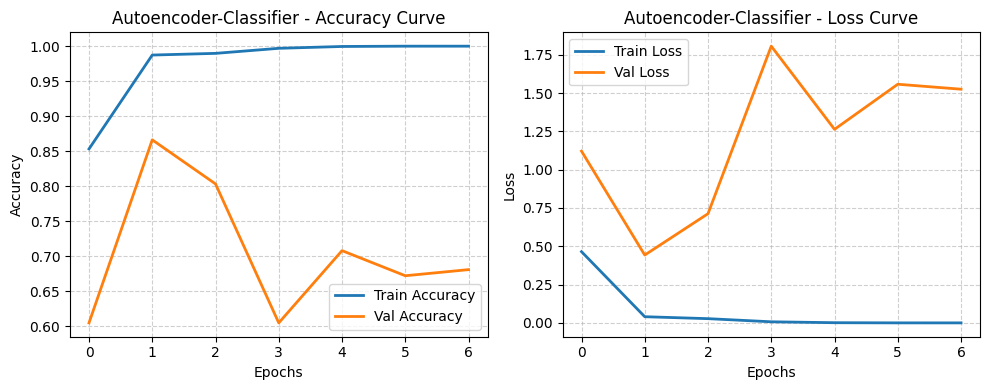

41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step

🔹 Autoencoder-Classifier Results:
Accuracy: 0.8696 | Precision: 0.8772 | Recall: 0.8696 | F1: 0.8673 | MCC: 0.8275


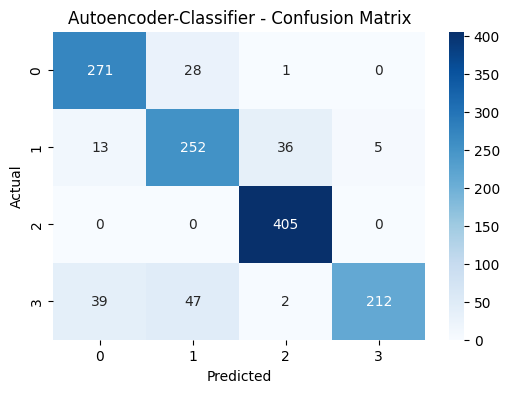


📋 Deep Learning Model Performance Summary:
                    Model  Accuracy  Precision    Recall        F1       MCC  \
0            MLP-Baseline  0.836003   0.864759  0.836003  0.835250  0.788413   
1                Deep-MLP  0.879481   0.896790  0.879481  0.881218  0.842839   
2  Autoencoder-Classifier  0.869565   0.877218  0.869565  0.867327  0.827485   

   Best_Val_Acc  Best_Val_Loss  
0      0.764654       0.789674  
1      0.900262       0.419894  
2      0.866142       0.442818  

🧩 Ensemble Fusion Results
Accuracy: 0.8802 | Precision: 0.8919 | Recall: 0.8802 | F1: 0.8797 | MCC: 0.8427


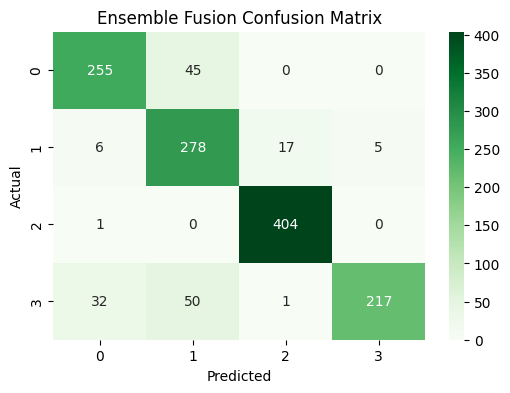

In [1]:
# ======================================================
# Phase 2: Deep Learning Fusion (Cleaned, Optimized & Visualized)
# ======================================================

import os, warnings
import numpy as np
import tensorflow as tf
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score, matthews_corrcoef
)

# ======================================================
# ⚙️ Logging and Warnings Control
# ======================================================
warnings.filterwarnings("ignore", category=UserWarning, module='keras')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'     # Suppress TensorFlow info/warnings
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'    # Disable oneDNN logs
tf.get_logger().setLevel('ERROR')
tf.autograph.set_verbosity(0)

# ======================================================
# 🧠 GPU Configuration — Use 1st GPU
# ======================================================
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.set_visible_devices(gpus[0], 'GPU')
        tf.config.experimental.set_memory_growth(gpus[0], True)
        print(f"✅ Using GPU: {gpus[0].name}")
    except Exception as e:
        print(f"⚠️ GPU config error, defaulting to CPU. Error: {e}")
else:
    print("⚠️ No GPU detected. Running on CPU.")

# ======================================================
# 🧩 Load Precomputed Feature Embeddings
# ======================================================
print("\n📥 Loading feature embeddings...")

resnet_train = np.load("/kaggle/input/embeddings/Embeddings/resnet18/resnet_train_features.npy")
resnet_test  = np.load("/kaggle/input/embeddings/Embeddings/resnet18/resnet_test_features.npy")

vgg_train = np.load("/kaggle/input/embeddings/Embeddings/vgg16/vgg_train_features.npy")
vgg_test  = np.load("/kaggle/input/embeddings/Embeddings/vgg16/vgg_test_features.npy")

eff_train = np.load("/kaggle/input/embeddings/Embeddings/EfficientNet-BO/efficientnet_train_features.npy")
eff_test  = np.load("/kaggle/input/embeddings/Embeddings/EfficientNet-BO/efficientnet_test_features.npy")

train_labels = np.load("/kaggle/input/embeddings/Embeddings/resnet18/resnet_train_labels.npy")
test_labels  = np.load("/kaggle/input/embeddings/Embeddings/resnet18/resnet_test_labels.npy")

# ======================================================
# ✅ Align Dataset Lengths
# ======================================================
min_train = min(resnet_train.shape[0], vgg_train.shape[0], eff_train.shape[0])
min_test  = min(resnet_test.shape[0], vgg_test.shape[0], eff_test.shape[0])

resnet_train, vgg_train, eff_train, train_labels = (
    resnet_train[:min_train], vgg_train[:min_train],
    eff_train[:min_train], train_labels[:min_train]
)
resnet_test, vgg_test, eff_test, test_labels = (
    resnet_test[:min_test], vgg_test[:min_test],
    eff_test[:min_test], test_labels[:min_test]
)

# ======================================================
# 🔗 Feature Fusion (Concatenate Embeddings)
# ======================================================
X_train = np.concatenate((resnet_train, vgg_train, eff_train), axis=1)
X_test  = np.concatenate((resnet_test, vgg_test, eff_test), axis=1)
num_classes = len(np.unique(train_labels))

print(f"✅ Combined Features — Train: {X_train.shape}, Test: {X_test.shape}, Classes: {num_classes}")

# ======================================================
# 🧱 Deep Learning Models
# ======================================================
def build_mlp_baseline(input_dim, num_classes):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(1024, activation='relu'),
        BatchNormalization(),
        Dropout(0.4),
        Dense(512, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])
    return model


def build_deep_mlp(input_dim, num_classes):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(2048, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(1024, activation='relu'),
        BatchNormalization(),
        Dropout(0.4),
        Dense(512, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(256, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])
    return model


def build_autoencoder_classifier(input_dim, num_classes):
    inp = Input(shape=(input_dim,))
    x = Dense(512, activation='relu')(inp)
    x = Dense(128, activation='relu')(x)
    x = Dense(512, activation='relu')(x)
    out = Dense(num_classes, activation='softmax')(x)
    model = Model(inp, out)
    return model

# ======================================================
# ⚡ Training & Evaluation with Validation Curves
# ======================================================
def train_and_evaluate(model, name, X_train, y_train, X_test, y_test, epochs=30, batch_size=64):
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    print(f"\n🚀 Training {name} ...")
    history = model.fit(
        X_train, y_train, validation_split=0.2,
        epochs=epochs, batch_size=batch_size,
        callbacks=[es], verbose=1
    )

    # ===============================
    # 📈 Validation Curves
    # ===============================
    hist = history.history
    plt.figure(figsize=(10, 4))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(hist['accuracy'], label='Train Accuracy', linewidth=2)
    plt.plot(hist['val_accuracy'], label='Val Accuracy', linewidth=2)
    plt.title(f'{name} - Accuracy Curve')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(hist['loss'], label='Train Loss', linewidth=2)
    plt.plot(hist['val_loss'], label='Val Loss', linewidth=2)
    plt.title(f'{name} - Loss Curve')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

    # ===============================
    # 📊 Evaluation Metrics
    # ===============================
    y_pred = np.argmax(model.predict(X_test), axis=1)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    mcc  = matthews_corrcoef(y_test, y_pred)

    print(f"\n🔹 {name} Results:")
    print(f"Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f} | MCC: {mcc:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # return model + metrics
    return model, {
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "MCC": mcc,
        "Best_Val_Acc": max(hist['val_accuracy']),
        "Best_Val_Loss": min(hist['val_loss'])
    }, y_pred

# ======================================================
# 🚀 Train All Models
# ======================================================
models_info = [
    ("MLP-Baseline", build_mlp_baseline(X_train.shape[1], num_classes)),
    ("Deep-MLP", build_deep_mlp(X_train.shape[1], num_classes)),
    ("Autoencoder-Classifier", build_autoencoder_classifier(X_train.shape[1], num_classes))
]

results, all_preds = [], []
for name, model in models_info:
    model, metrics, preds = train_and_evaluate(model, name, X_train, train_labels, X_test, test_labels)
    results.append(metrics)
    all_preds.append(preds)

# ======================================================
# 📊 Performance Summary
# ======================================================
results_df = pd.DataFrame(results)
print("\n📋 Deep Learning Model Performance Summary:")
print(results_df)

# ======================================================
# 🧠 Ensemble Fusion (Majority Voting)
# ======================================================
ensemble_preds = np.array(all_preds)
final_preds = np.apply_along_axis(lambda x: np.bincount(x).argmax(), axis=0, arr=ensemble_preds)

ens_acc  = accuracy_score(test_labels, final_preds)
ens_prec = precision_score(test_labels, final_preds, average='weighted', zero_division=0)
ens_rec  = recall_score(test_labels, final_preds, average='weighted', zero_division=0)
ens_f1   = f1_score(test_labels, final_preds, average='weighted', zero_division=0)
ens_mcc  = matthews_corrcoef(test_labels, final_preds)

print("\n🧩 Ensemble Fusion Results")
print(f"Accuracy: {ens_acc:.4f} | Precision: {ens_prec:.4f} | Recall: {ens_rec:.4f} | F1: {ens_f1:.4f} | MCC: {ens_mcc:.4f}")

cm = confusion_matrix(test_labels, final_preds)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.title("Ensemble Fusion Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()